In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

BASE    = r"C:\Users\Julian\Documents\SeptimoSemestre\Ingenieria de Datos\SkillScope"
DB_PATH = f"{BASE}/data/jobs.duckdb"

sns.set_theme(style="whitegrid")
print("Librerías cargadas ✓")

Librerías cargadas ✓


In [3]:
con = duckdb.connect(DB_PATH)

total_jobs   = con.execute("SELECT COUNT(*) FROM jobs").fetchone()[0]
total_skills = con.execute("SELECT COUNT(DISTINCT skill) FROM job_skills").fetchone()[0]
total_weeks  = con.execute("SELECT COUNT(DISTINCT week) FROM jobs").fetchone()[0]
total_companies = con.execute("SELECT COUNT(DISTINCT company) FROM jobs").fetchone()[0]

print(f"📋 Total ofertas:    {total_jobs:,}")
print(f"🛠️  Skills únicas:    {total_skills:,}")
print(f"📅 Semanas de datos: {total_weeks}")
print(f"🏢 Empresas:         {total_companies:,}")

📋 Total ofertas:    1,149,342
🛠️  Skills únicas:    2,832,493
📅 Semanas de datos: 2
🏢 Empresas:         69,384


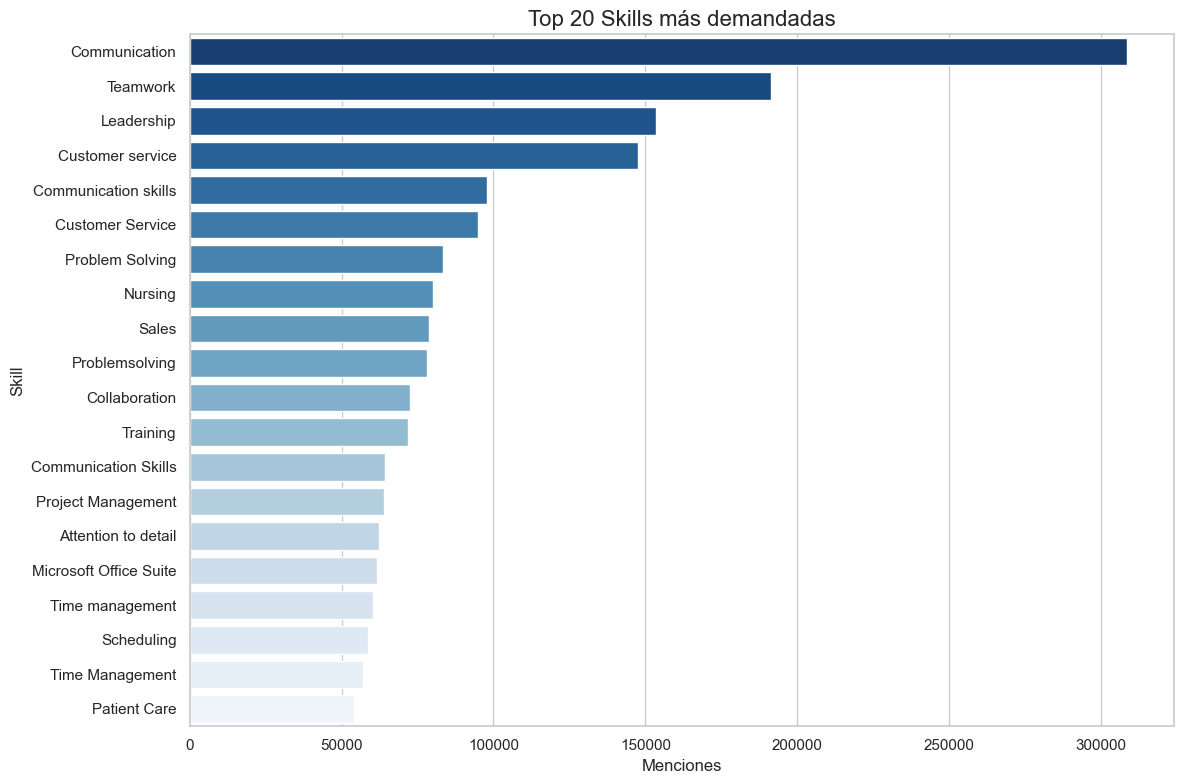

In [4]:
df_top_skills = con.execute("""
    SELECT skill, COUNT(*) AS menciones
    FROM job_skills
    GROUP BY skill
    ORDER BY menciones DESC
    LIMIT 20
""").df()

plt.figure(figsize=(12, 8))
sns.barplot(data=df_top_skills, x='menciones', y='skill', palette='Blues_r')
plt.title('Top 20 Skills más demandadas', fontsize=16)
plt.xlabel('Menciones')
plt.ylabel('Skill')
plt.tight_layout()
plt.show()

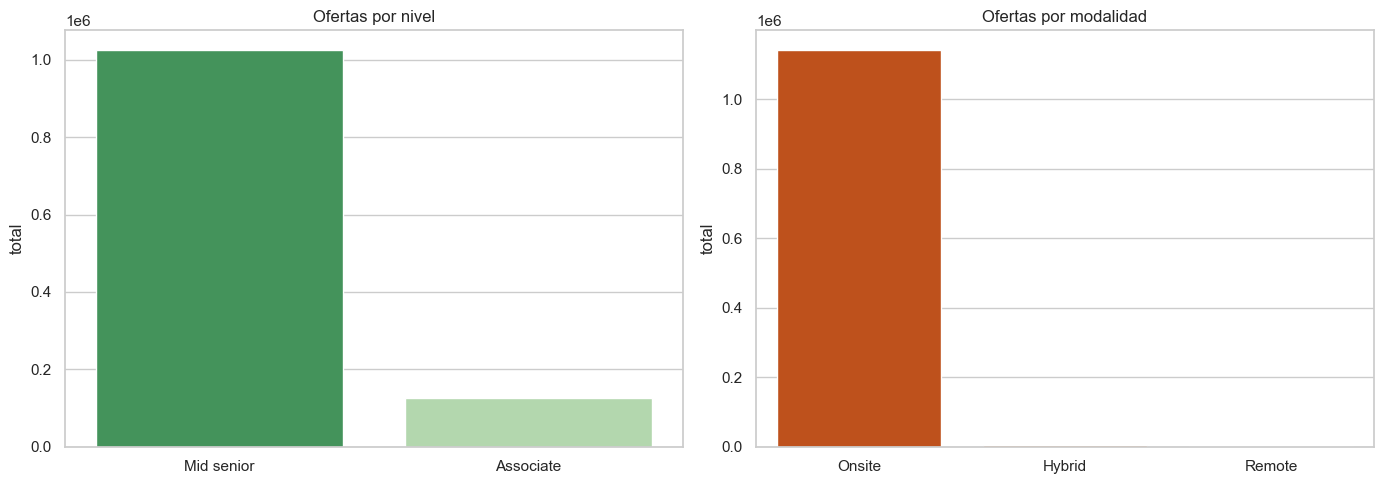

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por nivel
df_level = con.execute("""
    SELECT job_level, COUNT(*) AS total
    FROM jobs GROUP BY job_level ORDER BY total DESC
""").df()
sns.barplot(data=df_level, x='job_level', y='total', palette='Greens_r', ax=axes[0])
axes[0].set_title('Ofertas por nivel')
axes[0].set_xlabel('')

# Por modalidad
df_type = con.execute("""
    SELECT job_type, COUNT(*) AS total
    FROM jobs GROUP BY job_type ORDER BY total DESC
""").df()
sns.barplot(data=df_type, x='job_type', y='total', palette='Oranges_r', ax=axes[1])
axes[1].set_title('Ofertas por modalidad')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

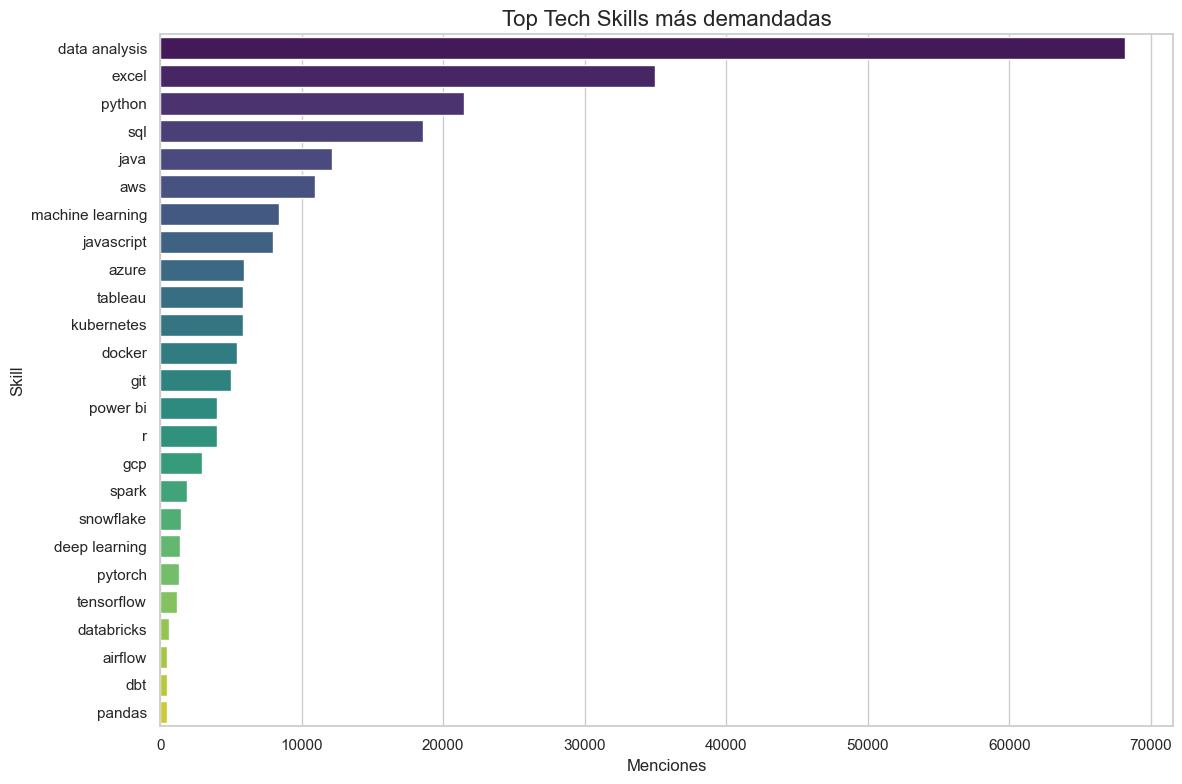

In [6]:
# Normalizar skills (lowercase + strip)
df_top_tech = con.execute("""
    SELECT 
        LOWER(TRIM(skill)) AS skill_norm,
        COUNT(*) AS menciones
    FROM job_skills
    WHERE LOWER(TRIM(skill)) IN (
        'python', 'sql', 'java', 'javascript', 'r', 
        'spark', 'aws', 'azure', 'gcp', 'docker',
        'kubernetes', 'tensorflow', 'pytorch', 'pandas',
        'airflow', 'dbt', 'snowflake', 'databricks',
        'tableau', 'power bi', 'excel', 'git',
        'machine learning', 'deep learning', 'data analysis'
    )
    GROUP BY skill_norm
    ORDER BY menciones DESC
""").df()

plt.figure(figsize=(12, 8))
sns.barplot(data=df_top_tech, x='menciones', y='skill_norm', palette='viridis')
plt.title('Top Tech Skills más demandadas', fontsize=16)
plt.xlabel('Menciones')
plt.ylabel('Skill')
plt.tight_layout()
plt.show()

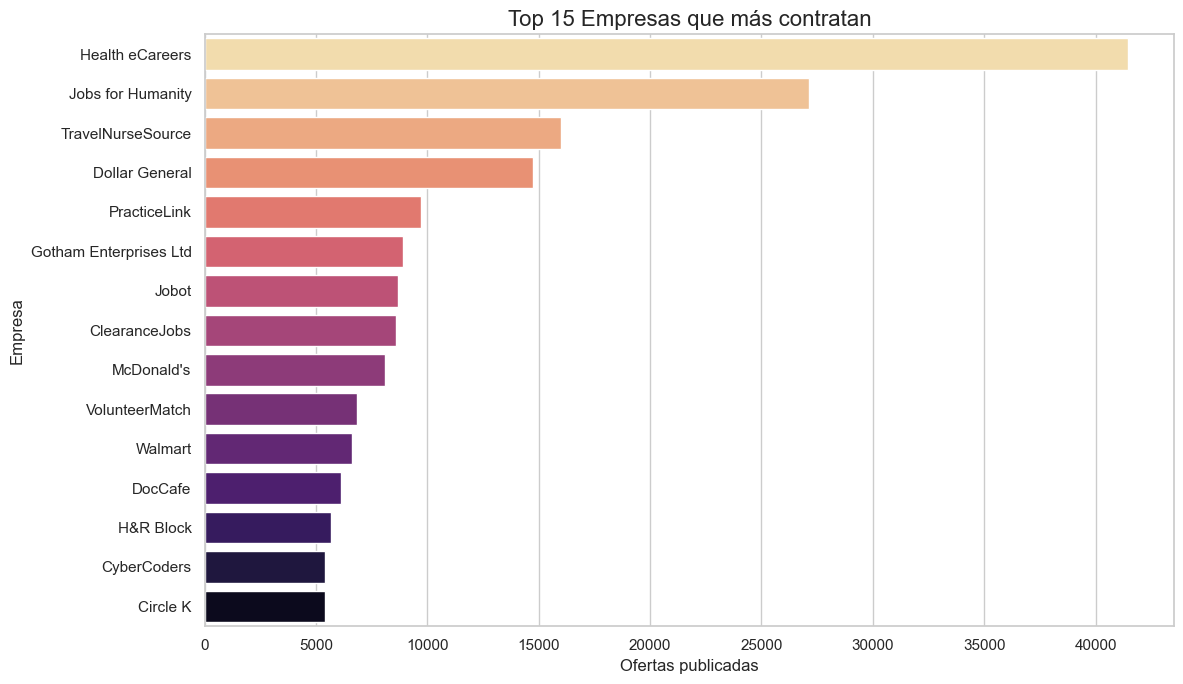

In [7]:
df_companies = con.execute("""
    SELECT company, COUNT(*) AS ofertas
    FROM jobs
    GROUP BY company
    ORDER BY ofertas DESC
    LIMIT 15
""").df()

plt.figure(figsize=(12, 7))
sns.barplot(data=df_companies, x='ofertas', y='company', palette='magma_r')
plt.title('Top 15 Empresas que más contratan', fontsize=16)
plt.xlabel('Ofertas publicadas')
plt.ylabel('Empresa')
plt.tight_layout()
plt.show()

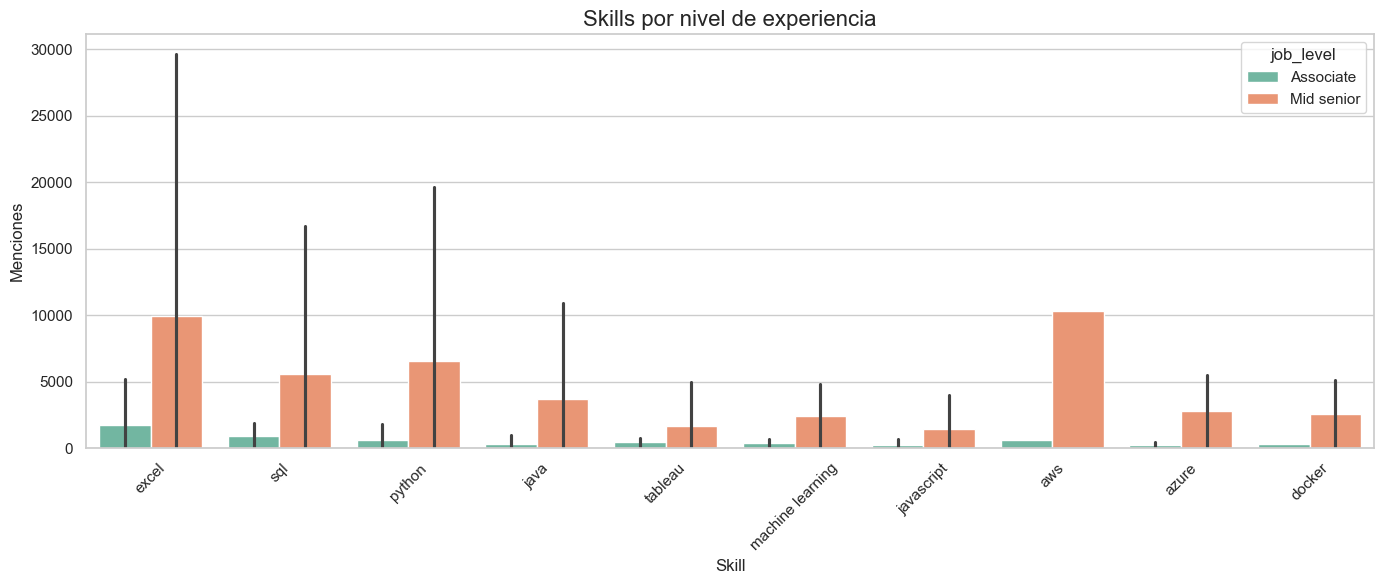

In [8]:
df_level_skills = con.execute("""
    SELECT 
        j.job_level,
        LOWER(TRIM(js.skill)) AS skill,
        COUNT(*) AS menciones
    FROM jobs j
    JOIN job_skills js ON j.job_link = js.job_link
    WHERE LOWER(TRIM(js.skill)) IN (
        'python', 'sql', 'aws', 'java', 'excel',
        'machine learning', 'docker', 'javascript', 'azure', 'tableau'
    )
    GROUP BY j.job_level, skill
    ORDER BY j.job_level, menciones DESC
""").df()

plt.figure(figsize=(14, 6))
sns.barplot(data=df_level_skills, x='skill', y='menciones', hue='job_level', palette='Set2')
plt.title('Skills por nivel de experiencia', fontsize=16)
plt.xlabel('Skill')
plt.ylabel('Menciones')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

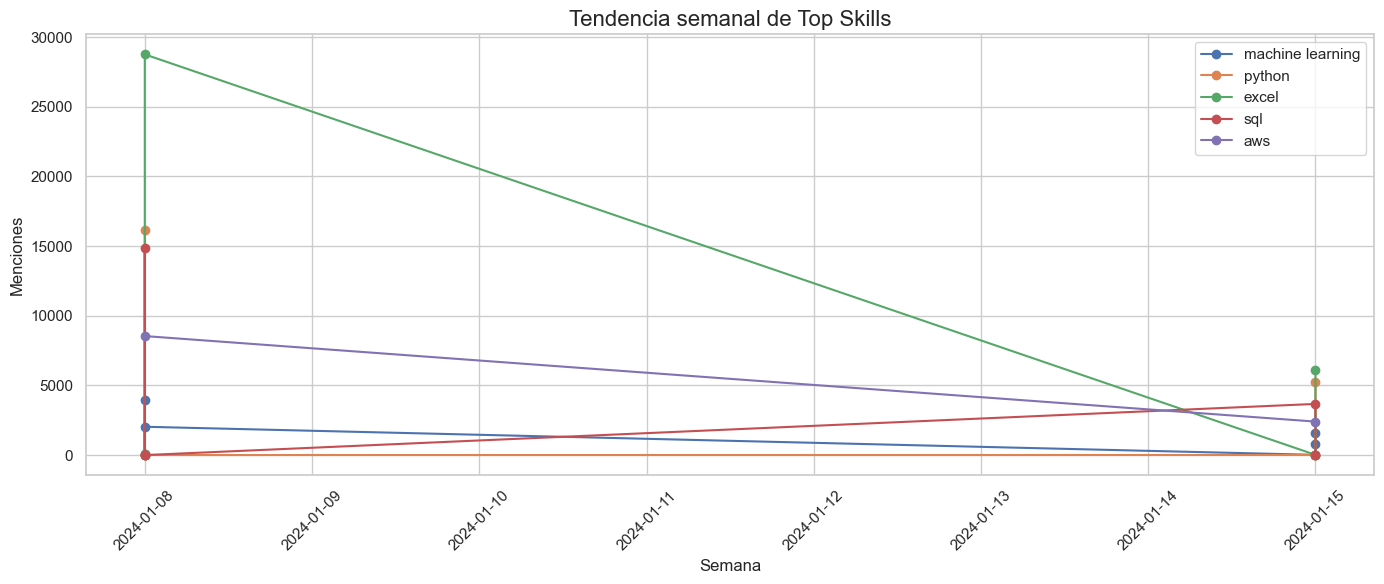

In [9]:
df_trend = con.execute("""
    SELECT 
        j.week,
        LOWER(TRIM(js.skill)) AS skill,
        COUNT(*) AS menciones
    FROM jobs j
    JOIN job_skills js ON j.job_link = js.job_link
    WHERE LOWER(TRIM(js.skill)) IN ('python', 'sql', 'aws', 'excel', 'machine learning')
    GROUP BY j.week, skill
    ORDER BY j.week ASC
""").df()

df_trend['week'] = pd.to_datetime(df_trend['week'])

plt.figure(figsize=(14, 6))
for skill in df_trend['skill'].unique():
    data = df_trend[df_trend['skill'] == skill]
    plt.plot(data['week'], data['menciones'], marker='o', label=skill)

plt.title('Tendencia semanal de Top Skills', fontsize=16)
plt.xlabel('Semana')
plt.ylabel('Menciones')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

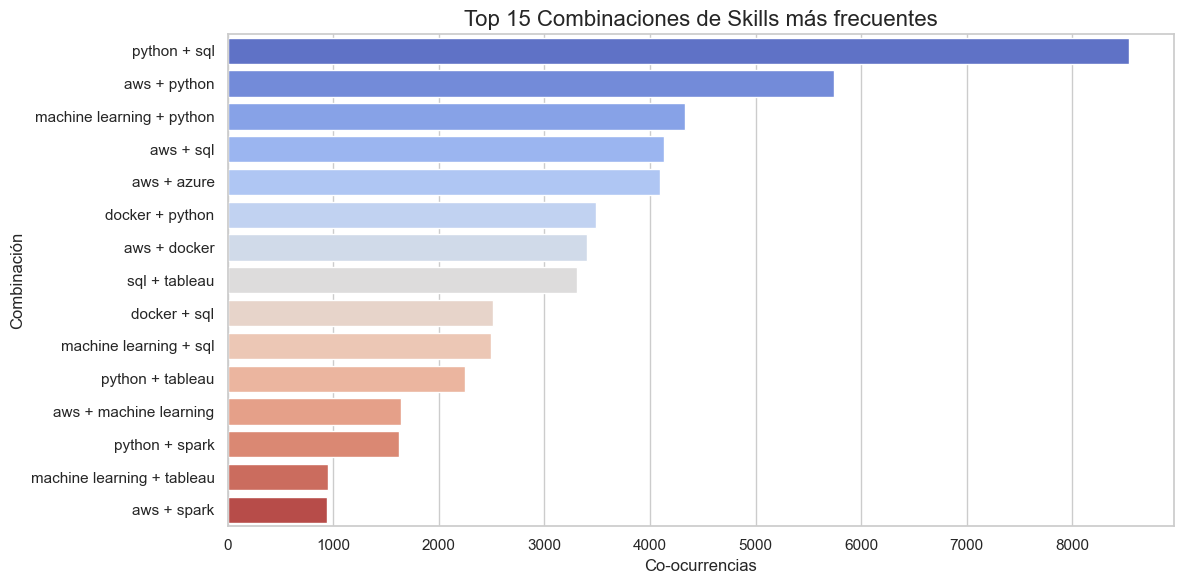

In [10]:
df_combos = con.execute("""
    SELECT 
        LOWER(TRIM(a.skill)) AS skill_a,
        LOWER(TRIM(b.skill)) AS skill_b,
        COUNT(*) AS co_ocurrencias
    FROM job_skills a
    JOIN job_skills b ON a.job_link = b.job_link
    WHERE LOWER(TRIM(a.skill)) < LOWER(TRIM(b.skill))
    AND LOWER(TRIM(a.skill)) IN ('python', 'sql', 'aws', 'machine learning', 'docker')
    AND LOWER(TRIM(b.skill)) IN ('python', 'sql', 'aws', 'machine learning', 'docker', 'azure', 'spark', 'tableau')
    GROUP BY skill_a, skill_b
    ORDER BY co_ocurrencias DESC
    LIMIT 15
""").df()

plt.figure(figsize=(12, 6))
df_combos['combinacion'] = df_combos['skill_a'] + ' + ' + df_combos['skill_b']
sns.barplot(data=df_combos, x='co_ocurrencias', y='combinacion', palette='coolwarm')
plt.title('Top 15 Combinaciones de Skills más frecuentes', fontsize=16)
plt.xlabel('Co-ocurrencias')
plt.ylabel('Combinación')
plt.tight_layout()
plt.show()

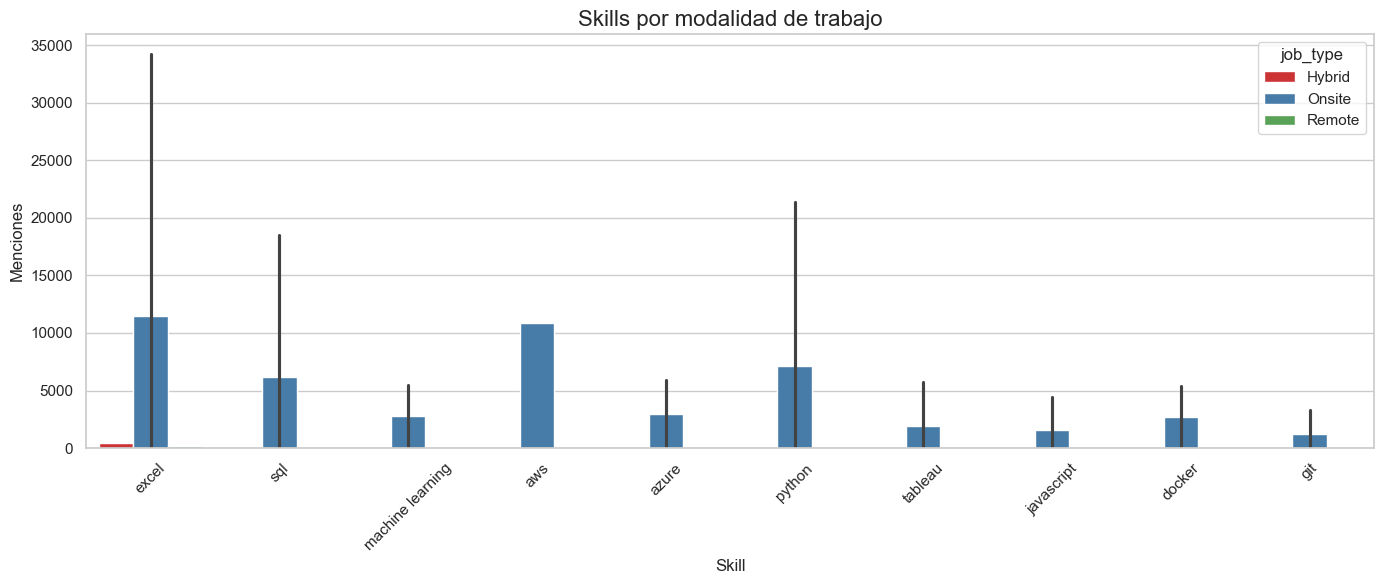

In [11]:
df_type_skills = con.execute("""
    SELECT 
        j.job_type,
        LOWER(TRIM(js.skill)) AS skill,
        COUNT(*) AS menciones
    FROM jobs j
    JOIN job_skills js ON j.job_link = js.job_link
    WHERE LOWER(TRIM(js.skill)) IN (
        'python', 'sql', 'aws', 'excel', 'machine learning',
        'docker', 'javascript', 'azure', 'tableau', 'git'
    )
    AND j.job_type IN ('Onsite', 'Hybrid', 'Remote')
    GROUP BY j.job_type, skill
    ORDER BY j.job_type, menciones DESC
""").df()

plt.figure(figsize=(14, 6))
sns.barplot(data=df_type_skills, x='skill', y='menciones', hue='job_type', palette='Set1')
plt.title('Skills por modalidad de trabajo', fontsize=16)
plt.xlabel('Skill')
plt.ylabel('Menciones')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()